In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import sys
sys.path.append('../python')
import threepoint

# Simulation-based covariance

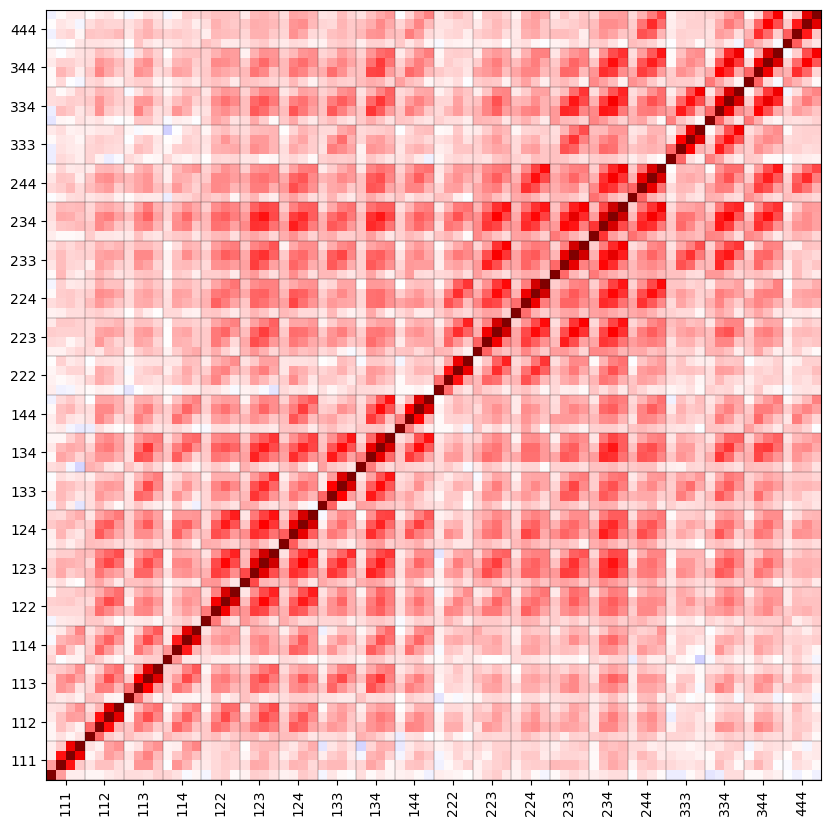

In [4]:
#796 sims
full_cov_weighted = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-24FEBRUARY2025_WITH_COV.fits')
cov = full_cov_weighted[2].data
_ = np.diag(cov)
rcc = cov/np.outer(_, _)**0.5
# plot
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.pcolormesh(rcc, cmap='seismic', vmin=-1, vmax=1)
for v in range(20):
    ax.axhline(v*4, color='k', lw=0.2)
    ax.axvline(v*4, color='k', lw=0.2)
# label
labels = []
for i in range(4):
    for j in range(i, 4):
        for k in range(j, 4):
            labels.append(f'{i+1}{j+1}{k+1}')
ax.set_xticks(4*np.arange(20)+2, labels, rotation=90)
ax.set_yticks(4*np.arange(20)+2, labels)
#fig.savefig('covariance_796simbased_map3.png', bbox_inches='tight')
plt.show()

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.

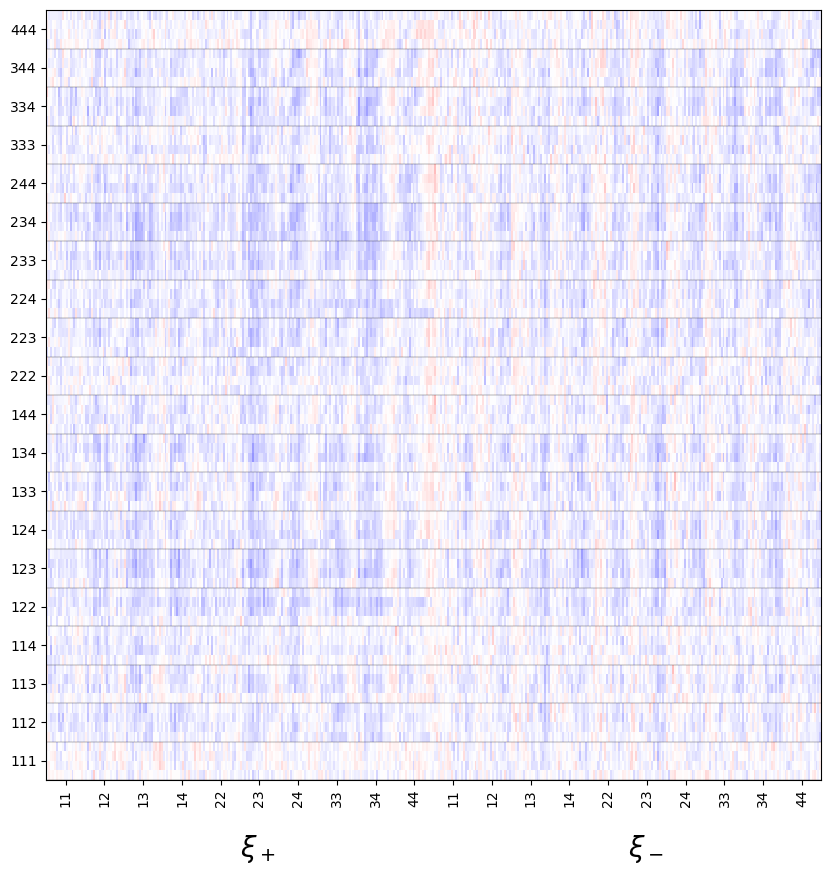

In [5]:
#cross cov
full_cov_weighted = np.load('../data/dv/average_map3_796sims/xip_xim_map3_covariance_8ARCMINCUT_24Feb25.npy')
allcov = full_cov_weighted
_ = np.diag(allcov)
rcc = allcov/np.outer(_, _)**0.5
print(np.diag(rcc))
rcc_crosscov = rcc[400:,:400]
print(np.max(rcc_crosscov))
# plot
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.pcolormesh(rcc_crosscov, cmap='seismic', vmin=-1, vmax=1)
for v in range(20):
    ax.axhline(v*4, color='k', lw=0.2)
    #ax.axvline(v*4, color='k', lw=0.2)
# label
labels = []
for i in range(4):
    for j in range(i, 4):
        for k in range(j, 4):
            labels.append(f'{i+1}{j+1}{k+1}')
#ax.set_xticks(4*np.arange(20)+2, labels, rotation=90)
ax.set_yticks(4*np.arange(20)+2, labels)
labels2 = []
for i in range(4):
    for j in range(i, 4):
        labels2.append(f'{i+1}{j+1}')
labels2 = labels2 + labels2
ax.set_xticks(20*np.arange(20)+10, labels2, rotation=90)
ax.text(100, -8, r'$\xi_+$', fontsize=20)
ax.text(300, -8, r'$\xi_-$', fontsize=20)
fig.savefig('cross_covariance_796simbased_map3.png', bbox_inches='tight')
#plt.show()

## analytic covariance for 2pt

In [51]:
from astropy.io import fits
hdul = fits.open('../data/dv/sim_2pt-NLA-cosmoDESY3.fits')
cov = hdul['COVMAT'].data[:400,:400]
_ = np.diag(cov)
rcc = cov/np.outer(_, _)**0.5

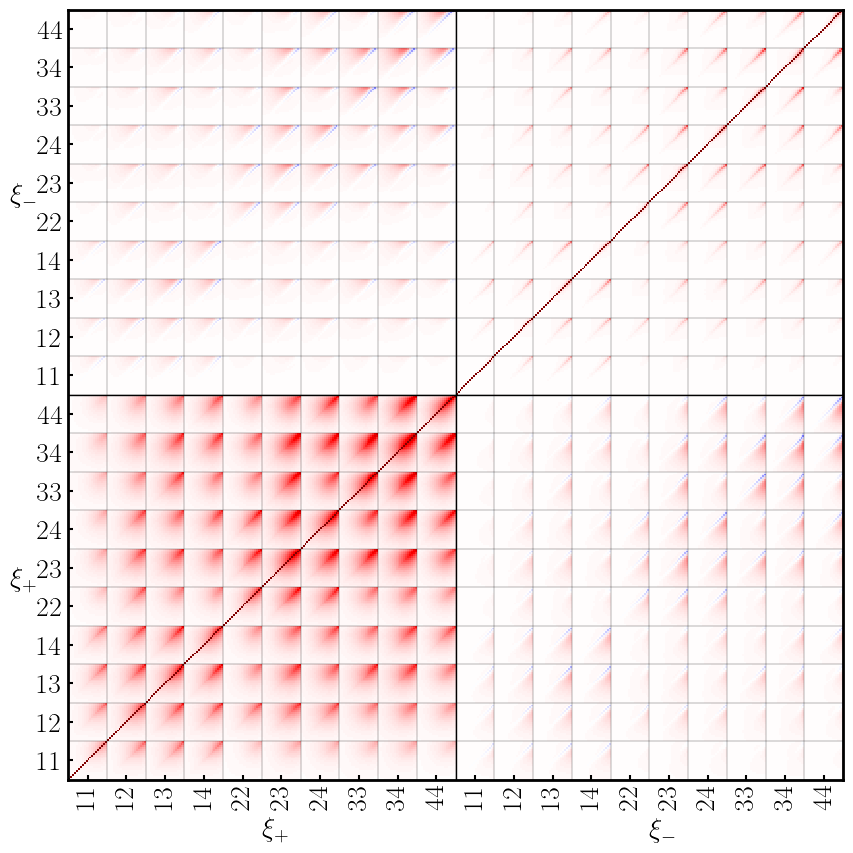

In [52]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.pcolormesh(rcc, vmin=-1, vmax=1)
for v in [200, 400]:
    ax.axhline(v, color='k', lw=1)
    ax.axvline(v, color='k', lw=1)
for v in range(20):
    ax.axhline(v*20, color='k', lw=0.2)
    ax.axvline(v*20, color='k', lw=0.2)
# label
labels = []
for i in range(4):
    for j in range(i, 4):
        labels.append(f'{i+1}{j+1}')
labels = labels + labels
ax.set_xticks(20*np.arange(20)+10, labels, rotation=90)
ax.set_yticks(20*np.arange(20)+10, labels)
# xipm
ax.text(100, -30, r'$\xi_+$', fontsize=20)
ax.text(300, -30, r'$\xi_-$', fontsize=20)
ax.text(-30, 100, r'$\xi_+$', fontsize=20)
ax.text(-30, 300, r'$\xi_-$', fontsize=20)
fig.savefig('../plots/covariance_analytic_2pt.png', bbox_inches='tight')
plt.show()

In [6]:
cov = np.load('../data/dv/average_map3_796sims/xip_xim_map3_covariance_8ARCMINCUT_24Feb25.npy')[:400,:400]

In [7]:
_ = np.diag(cov)
rcc_sim = cov/np.outer(_, _)**0.5
# ana-based
hdul = fits.open('../data/dv/sim_2pt-NLA.fits')
cov = hdul['COVMAT'].data[:400,:400]
_ = np.diag(cov)
rcc_ana = cov/np.outer(_, _)**0.5

# Hetero
rcc = rcc_sim.copy()
_ = np.arange(rcc_sim.shape[0])
_ = _[None,:] < _[:,None]
rcc[_] = rcc_ana[_]

In [63]:
scale_cuts_xip = np.array([20,21,22,23,40,41,42,43,60,61,62,80,81,82,83,100,101,102,103,120,121,122,123,140,141,142,143,160,161,162,163,180,181,182])
scale_cuts_xim = np.concatenate((np.arange(200,210), np.arange(220,234),np.arange(240,254), np.arange(260,273), np.arange(280,294), np.arange(300,315), np.arange(320,335), np.arange(340,355), np.arange(360,375), np.arange(380,394)))
scale_cuts = np.concatenate((scale_cuts_xip, scale_cuts_xim))

cov_cut = np.delete(np.delete(cov, scale_cuts, axis=0), scale_cuts, axis=1)
cov_2_cut = np.delete(np.delete(cov_2, scale_cuts, axis=0), scale_cuts, axis=1)

moped_transformation_file = np.loadtxt('../data/moped/moped-moped-compress-2pt.txt')
ana_comp = np.dot(moped_transformation_file.T, np.dot(cov_cut, moped_transformation_file))
sim_comp = np.dot(moped_transformation_file.T, np.dot(cov_2_cut, moped_transformation_file))

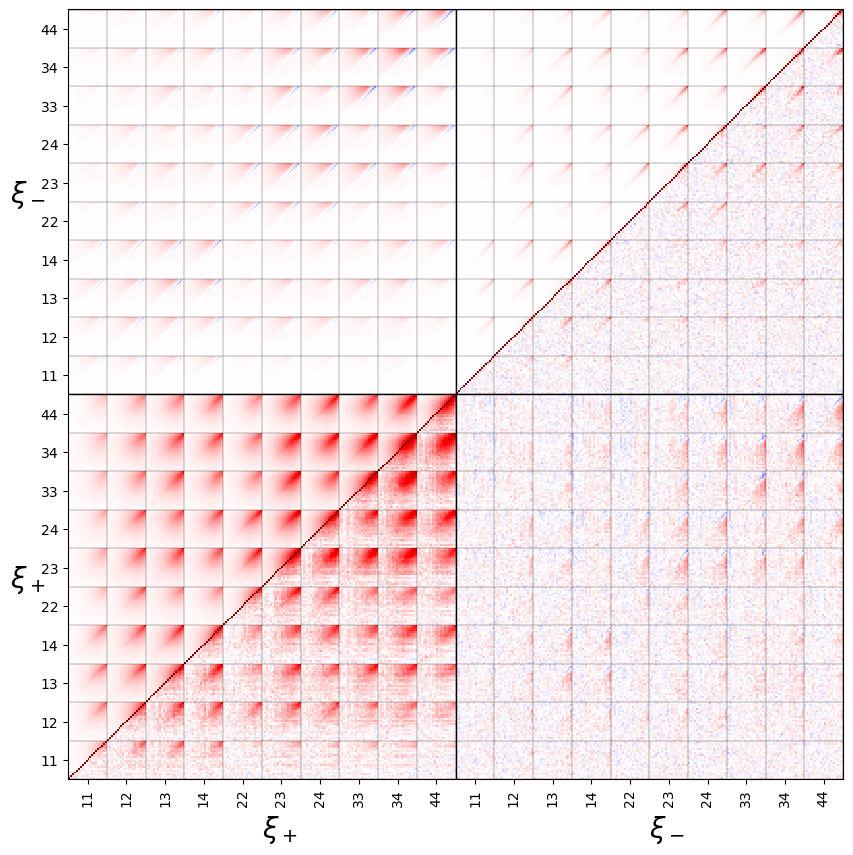

In [8]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.pcolormesh(rcc, vmin=-1, vmax=1, cmap='seismic')
for v in [200, 400]:
    ax.axhline(v, color='k', lw=1)
    ax.axvline(v, color='k', lw=1)
for v in range(20):
    ax.axhline(v*20, color='k', lw=0.2)
    ax.axvline(v*20, color='k', lw=0.2)
# label
labels = []
for i in range(4):
    for j in range(i, 4):
        labels.append(f'{i+1}{j+1}')
labels = labels + labels
ax.set_xticks(20*np.arange(20)+10, labels, rotation=90)
ax.set_yticks(20*np.arange(20)+10, labels)
# xipm
ax.text(100, -30, r'$\xi_+$', fontsize=20)
ax.text(300, -30, r'$\xi_-$', fontsize=20)
ax.text(-30, 100, r'$\xi_+$', fontsize=20)
ax.text(-30, 300, r'$\xi_-$', fontsize=20)
#fig.savefig('covariance_anasim_2pt_796sims_25Feb25.png', bbox_inches='tight')
plt.show()